# Numerical solution to TISE

We have appreciated that the approach to solve for the Time Dependent Schrodinger Equation (TDSE) is through the solution of the Time Independent Schrodinger Equation (TISE)

We have also looked that the solution to second order differential equations numerically is to

1. find the appropriate set of first order differential equation for the state.
2. find the recurrence relation for the state.

Let us apply the numerical method to the TISE.

# Step potential

Let us solve for the solution to the particle in a step potential.

$$
V(x)
=
\left\{
\begin{array}{ll}
0 & x<0 \\
1 & x\geq 0
\end{array}
\right.
$$

The TISE equation is given by

$$
\left( -\frac{\hbar^2}{2m}\frac{\mathrm{d^2}}{\mathrm{d}x^2} + V(x) \right)\psi (x) = E \psi (x)
$$

Let us define the wave-vector $k(x)$ as the measure of the kinetic energy $T(x)=E-V(x)$ content of the particle at position $x$

$$
k^2(x) = \frac{2m T(x)}{\hbar^2} = \frac{2m \left(E- V(x)\right)}{\hbar^2}
$$

Thus, the TISE can be written in terms of the wavevector $k(x)$ as

\begin{align}
\frac{\mathrm{d^2} \psi (x)}{\mathrm{d}x^2} &= - \frac{2m \left(E- V(x)\right)}{\hbar^2}\psi (x) \\
&= - k^2(x) \psi (x)
\end{align}

We have done a similar differential equation, the simple harmonic motion, where the paramter $\omega$ was a constant of motion. Here, the parameter $k(x)$ depends on the position of the particle.

So, let us apply the analysis of finite difference method to the TISE also and define the state of the particle by the 2-component ket $|\Psi\rangle$ as

$$
|\Psi\rangle
=
\left(
\begin{matrix}
\psi \\
v_\psi
\end{matrix}
\right)
,
$$

where $v_\psi$ is the velocity of particle in space

$$
v_\psi = \frac{\mathrm{d} \psi (x)}{\mathrm{d}x}
$$


Since we are dealing with time axis evolution, let us call the matrix that gives the recurrence relation as propagator $\tilde{P}$, so that

$$
|\Psi_n\rangle = \tilde{P} |\Psi_{n-1}\rangle,
$$

where the propagator is given by

$$
\tilde{P} =
\left[
\begin{matrix}
1  & \Delta x \\
- k_{n-1}^2 \Delta x    & 1
\end{matrix}
\right]
$$

In terms of the eigen energy, the propagator is given by

$$
\tilde{P} =
\left[
\begin{matrix}
1  & \Delta x \\
- \frac{2m \left(E- V_{n-1}\right)}{\hbar^2} \Delta x    & 1
\end{matrix}
\right]
$$

# Initial state

Let the wavefunction at time $x=0$ be $\psi(0)$. What is the velocity $v_\psi (0)$?

Or in other words, if the eigen energy is $E$, in the finite difference method, if the initial velocity is $\left(v_\psi\right)_0$, then let us make the physical assumption that far from the step, the kinetic energy does not change, therefore, after the propagates the state, the velocity of psi is unchanged.

$$
\left(
\begin{matrix}
\psi_1 \\
\left(v_\psi\right)_1
\end{matrix}
\right)
=
\left[
\begin{matrix}
1  & \Delta x \\
- \frac{2m \left(E- V_{n-1}\right)}{\hbar^2} \Delta x    & 1
\end{matrix}
\right]
\left(
\begin{matrix}
\psi_0 \\
\left(v_\psi\right)_0
\end{matrix}
\right)
$$

Here, we assume

$$
\left(v_\psi\right)_1 = \left(v_\psi\right)_0,
$$

so that



In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
m = 1
hbar = 1

In [ ]:
dx = 1e-4
xmin, xmax = -10.0, 10.0
V0 = 1
xs = np.arange(xmin, xmax+dx, dx)

In [ ]:
def zero_potential(x):
    return 0.0

In [ ]:
def step_potential(x):
    if x < 0.0:
        return 0.0
    else:
        return V0

In [ ]:
# initial ket (psi0, vpsi0) = (0, 1)
ket0 = np.array([0, 1])

In [ ]:
def propagator(ket, step, x, E, potential):
    psi, vpsi = ket
    #ksq = 2.0*(E-zero_potential(x))
    #ksq = 2.0*(E-step_potential(x))
    ksq = 2.0*(E-potential(x))
    stepper = np.array([[1, step], [-1.0*ksq*step, 1]])
    evolved_ket = stepper.dot(ket)
    return evolved_ket

In [ ]:
def get_state(E, potential):
    """Return the wavefunction for a given energy"""
    kets = np.zeros((len(xs),2))
    for i in range(len(xs)):
        x = xs[i]
        if i==0:
            evolved_ket = ket0
            kets[i] = evolved_ket
        else:
            evolved_ket = propagator(kets[i-1], dx, x, E, potential)
            kets[i] = evolved_ket
    state = kets
    return state

In [ ]:
state = get_state(1.5, step_potential)

In [ ]:
pots = np.array([step_potential(x) for x in xs])

In [ ]:
psis, vpsis = state[:,0], state[:,1]

Text(0.5, 1.0, 'step potential')

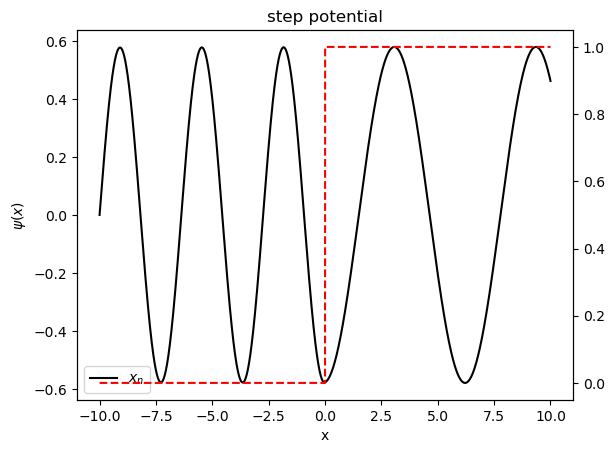

In [ ]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$x_n$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label=r'$V(x)=0$')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()

#ax2.tick_params(labelcolor='r')
#ax2.set_xlabel('v')
#ax2.legend()
ax.set_title('step potential')

# Semi classical approximation

The analysis of step potential captures the different kinetic energies of the particle in the two regions. However, it fails to capture the amplitude variation that is a measure of the transmission and reflection of the wave at the edge.

If we assume that the potential is smoothly varying function of x instead of the step potential, then there is a possibility of capturing the reduction of the amplitude as the wave approaches the step.

The step function can be substituted  by the Fermi-Dirac distribution at finite temperature

$$
V(x) = V_0\frac{1}{1 + \exp \left( \frac{-x}{T}\right)},
$$

where $T$ is a fictitious temperature with units of "position". So in the neighbourhood of step with width of the order of $T$, the potential continuously varies from zero to $V_0$.

In [ ]:
# globals

T = 1

In [ ]:
def smooth_step_potential(x):
    return V0/(1 + np.exp(-1.0*x/T))

In [ ]:
pots = np.array([smooth_step_potential(x) for x in xs])

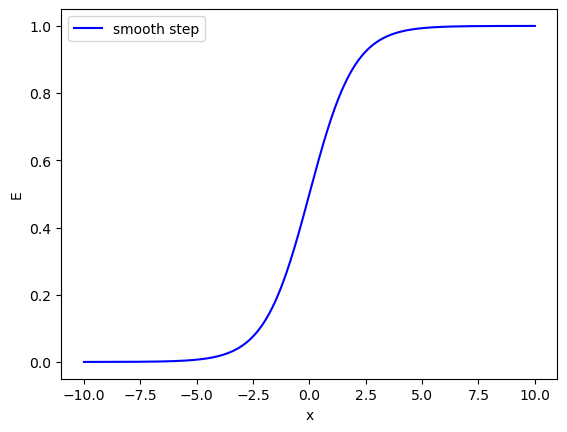

In [ ]:
# Draw the smooth step.

fig, ax = plt.subplots()
ax.plot(xs, pots, 'b-', label='smooth step')
ax.set_xlabel('x')
ax.set_ylabel('E')
ax.legend()

In [ ]:
state = get_state(0.5, smooth_step_potential)

In [ ]:
pots = np.array([smooth_step_potential(x) for x in xs])

In [ ]:
psis, vpsis = state[:,0], state[:,1]

Text(0.5, 1.0, 'step potential')

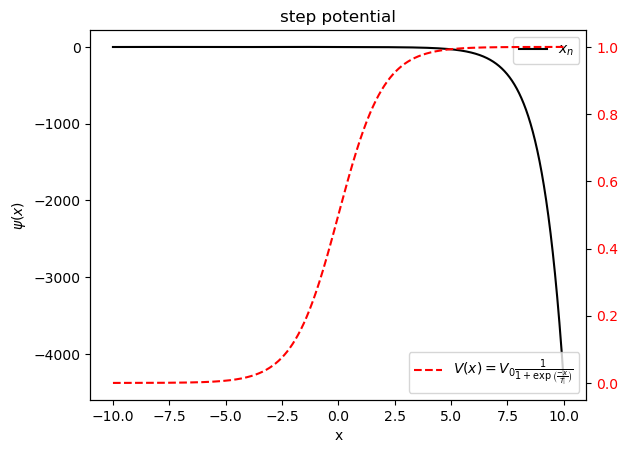

In [ ]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$x_n$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label=r'$V(x) = V_0\frac{1}{1 + \exp \left( \frac{-x}{T}\right)}$')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()

ax2.tick_params(labelcolor='r')
ax2.set_xlabel('v')
ax2.legend(loc ='lower right')
ax.set_title('step potential')

In [ ]:
def inverse_smooth_step_potential(x):
    return smooth_step_potential(-1.0*x)

In [ ]:
pots = np.array([inverse_smooth_step_potential(x) for x in xs])

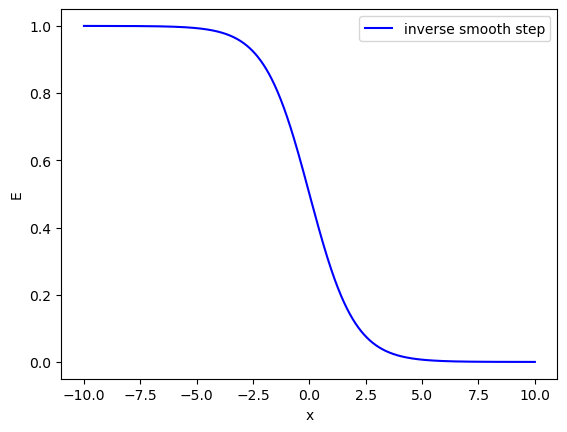

In [ ]:
# Draw the inverse smooth step.

fig, ax = plt.subplots()
ax.plot(xs, pots, 'b-', label='inverse smooth step')
ax.set_xlabel('x')
ax.set_ylabel('E')
ax.legend()

In [ ]:
state = get_state(1.5, inverse_smooth_step_potential)

In [ ]:
pots = np.array([inverse_smooth_step_potential(x) for x in xs])

In [ ]:
psis, vpsis = state[:,0], state[:,1]

Text(0.5, 1.0, 'realistic step potential')

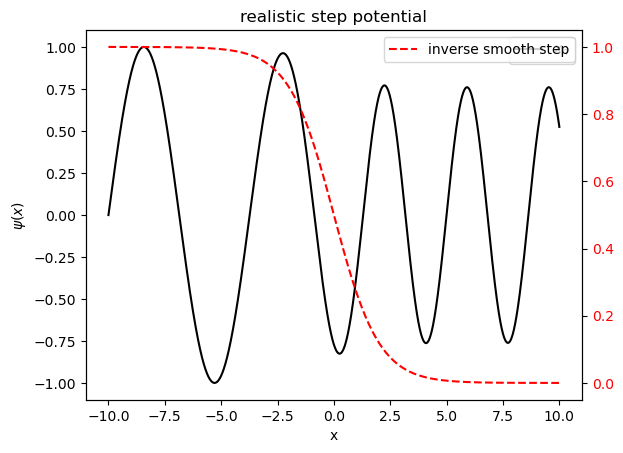

In [ ]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$x_n$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label=r'inverse smooth step')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()

ax2.tick_params(labelcolor='r')
ax2.set_xlabel('V(x)')
ax2.legend()
ax.set_title('realistic step potential')

In [ ]:
state = get_state(0.5, inverse_smooth_step_potential)

In [ ]:
pots = np.array([inverse_smooth_step_potential(x) for x in xs])

In [ ]:
psis, vpsis = state[:,0], state[:,1]

Text(0.5, 1.0, 'realistic step potential')

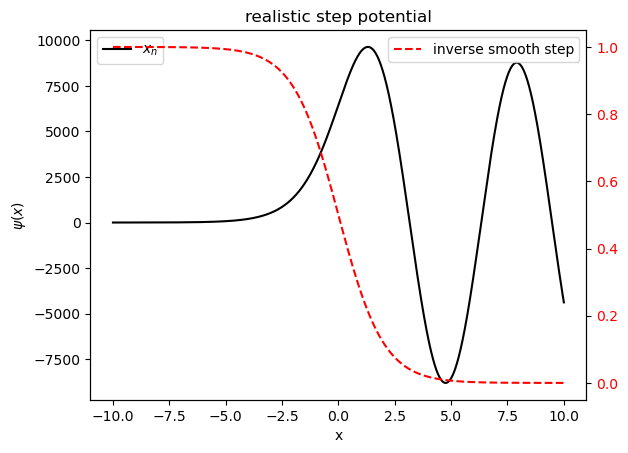

In [ ]:
fig, ax = plt.subplots()
ax.plot(xs, psis, 'k-', label=r'$x_n$')
ax2 = ax.twinx()
ax2.plot(xs, pots, 'r--', label=r'inverse smooth step')
ax.set_xlabel('x')
ax.set_ylabel(r'$\psi(x)$')
ax.legend()

ax2.tick_params(labelcolor='r')
ax2.set_xlabel('V(x)')
ax2.legend()
ax.set_title('realistic step potential')

Let us create a widget based application that solves the TISE. The application needs to have the following widgets as a bare minimum

- Energy
- Initial state
- Choice of potential

The secondary widgets are

- step size